In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Słownik tłumaczeń krajów na język polski
country_translation = {
    'Austria': 'Austria',
    'Belgium': 'Belgia',
    'Bulgaria': 'Bułgaria',
    'Croatia': 'Chorwacja',
    'Cyprus': 'Cypr',
    'Czech Republic': 'Czechy',
    'Denmark': 'Dania',
    'Estonia': 'Estonia',
    'Finland': 'Finlandia',
    'France': 'Francja',
    'Germany': 'Niemcy',
    'Greece': 'Grecja',
    'Hungary': 'Węgry',
    'Iceland': 'Islandia',
    'Ireland': 'Irlandia',
    'Italy': 'Włochy',
    'Latvia': 'Łotwa',
    'Liechtenstein': 'Liechtenstein',
    'Lithuania': 'Litwa',
    'Luxembourg': 'Luksemburg',
    'Malta': 'Malta',
    'Netherlands': 'Holandia',
    'Norway': 'Norwegia',
    'Poland': 'Polska',
    'Portugal': 'Portugalia',
    'Romania': 'Rumunia',
    'Slovakia': 'Słowacja',
    'Slovenia': 'Słowenia',
    'Spain': 'Hiszpania',
    'Sweden': 'Szwecja',
    'Switzerland': 'Szwajcaria',
    'Turkey': 'Turcja',
    'United Kingdom': 'Wielka Brytania'
}

# Słownik skrótów ISO 3166-1 alpha-3
iso_alpha_3 = {
    'Austria': 'AUT',
    'Belgium': 'BEL',
    'Bulgaria': 'BGR',
    'Croatia': 'HRV',
    'Cyprus': 'CYP',
    'Czech Republic': 'CZE',
    'Denmark': 'DNK',
    'Estonia': 'EST',
    'Finland': 'FIN',
    'France': 'FRA',
    'Germany': 'DEU',
    'Greece': 'GRC',
    'Hungary': 'HUN',
    'Iceland': 'ISL',
    'Ireland': 'IRL',
    'Italy': 'ITA',
    'Latvia': 'LVA',
    'Liechtenstein': 'LIE',
    'Lithuania': 'LTU',
    'Luxembourg': 'LUX',
    'Malta': 'MLT',
    'Netherlands': 'NLD',
    'Norway': 'NOR',
    'Poland': 'POL',
    'Portugal': 'PRT',
    'Romania': 'ROU',
    'Slovakia': 'SVK',
    'Slovenia': 'SVN',
    'Spain': 'ESP',
    'Sweden': 'SWE',
    'Switzerland': 'CHE',
    'Turkey': 'TUR',
    'United Kingdom': 'GBR'
}



In [ ]:
data = pd.read_csv('AF_Fleet.csv')

data.fillna(0, inplace=True)
#print(data.head(10))
data['Electric Cars'] = data['BEV'] + data['PHEV']
sorted_data = data.sort_values(by='Electric Cars', ascending=False)
sorted_data.rename(columns={'Category':'Country'}, inplace=True)
print(sorted_data.head(20))



           Country      BEV     PHEV      H2        LPG        CNG  LNG  \
10         Germany  2126719  1083447  1775.0   319123.0    87762.0  0.0   
32  United Kingdom  1738161   867695   277.0    23890.0        0.0  0.0   
9           France  1535021   814250  1550.0   329257.0    15115.0  0.0   
21     Netherlands   681210   483312   686.0   125770.0     5054.0  9.0   
22          Norway   931803   209132   154.0        0.0      536.0  0.0   
29          Sweden   459316   339563    46.0       15.0    39834.0  0.0   
1          Belgium   426993   355314   111.0    33569.0    16167.0  0.0   
15           Italy   366363   357312    59.0  2862160.0  1096205.0  0.0   
6          Denmark   505298   131388    43.0       15.0      172.0  0.0   
28           Spain   292351   323532   118.0   211260.0    22436.0  0.0   
30     Switzerland   268256   125180   300.0      101.0    16775.0  0.0   
24        Portugal   219540   159227     7.0    89826.0      299.0  0.0   
31          Turkey   3157

In [4]:
# Dodanie kolumn z tłumaczeniami i skrótami do DataFrame
sorted_data['Kraj'] = sorted_data['Country'].map(country_translation)
sorted_data['Skrot'] = sorted_data['Country'].map(iso_alpha_3)

# Wyświetlenie pierwszych kilku wierszy z nowymi kolumnami
print(sorted_data.head())

           Country      BEV     PHEV      H2       LPG      CNG  LNG  \
10         Germany  2126719  1083447  1775.0  319123.0  87762.0  0.0   
32  United Kingdom  1738161   867695   277.0   23890.0      0.0  0.0   
9           France  1535021   814250  1550.0  329257.0  15115.0  0.0   
21     Netherlands   681210   483312   686.0  125770.0   5054.0  9.0   
22          Norway   931803   209132   154.0       0.0    536.0  0.0   

    Electric Cars             Kraj Skrot  
10        3210166           Niemcy   DEU  
32        2605856  Wielka Brytania   GBR  
9         2349271          Francja   FRA  
21        1164522         Holandia   NLD  
22        1140935         Norwegia   NOR  


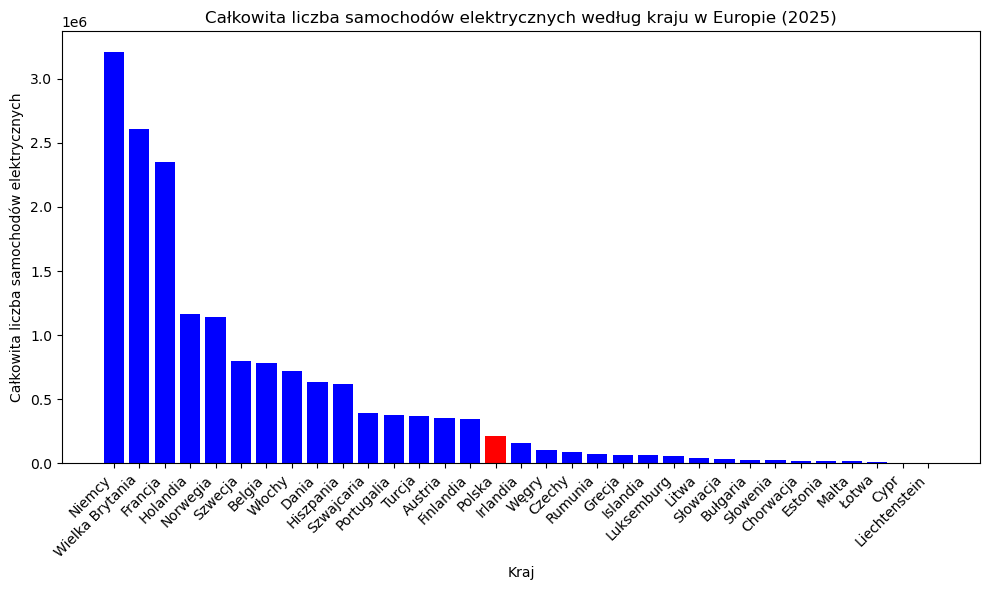

In [5]:
# Tworzenie wykresu słupkowego dla całkowitej liczby samochodów elektrycznych
colors = ['red' if country == 'Poland' else 'blue' for country in sorted_data['Country']]
plt.figure(figsize=(10, 6))
plt.bar(sorted_data['Kraj'], sorted_data['Electric Cars'], color=colors)
plt.xlabel('Kraj')
plt.ylabel('Całkowita liczba samochodów elektrycznych')
plt.title('Całkowita liczba samochodów elektrycznych według kraju w Europie (2025)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Wczytanie danych z pliku AF_Percentage_Fleet.csv
percentage_data = pd.read_csv('AF_Percentage_Fleet.csv')

# Uzupełnienie brakujących wartości zerami
percentage_data.fillna(0, inplace=True)

# Zmiana nazwy kolumny 'Category' na 'Country', jeśli istnieje
percentage_data.rename(columns={'Category': 'Country'}, inplace=True)

# Dodanie kolumn z tłumaczeniami i skrótami do DataFrame
percentage_data['Kraj'] = percentage_data['Country'].map(country_translation)
percentage_data['Skrot'] = percentage_data['Country'].map(iso_alpha_3)

# Wyświetlenie pierwszych kilku wierszy z nowymi kolumnami
print(percentage_data.head())

    Country   BEV  PHEV   H2   LPG   CNG  LNG       Kraj Skrot
0   Austria  3.72  1.30  0.0  0.01  0.10  0.0    Austria   AUT
1   Belgium  3.71  4.62  0.0  0.44  0.23  0.0     Belgia   BEL
2  Bulgaria  0.56  0.17  0.0  5.01  0.69  0.0   Bułgaria   BGR
3   Croatia  0.48  0.37  0.0  2.52  0.01  0.0  Chorwacja   HRV
4    Cyprus  0.29  0.19  0.0  0.03  0.00  0.0       Cypr   CYP


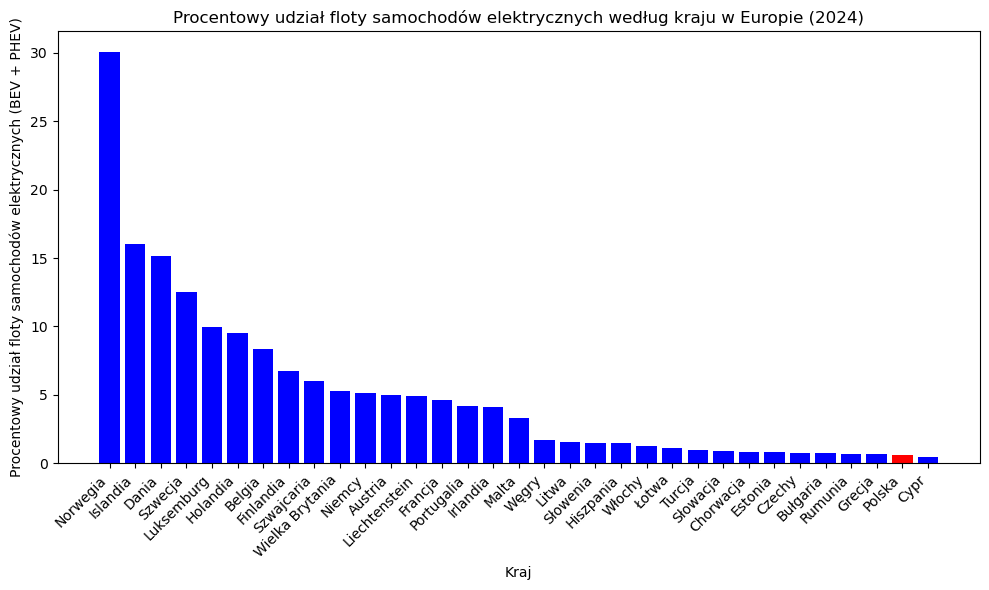

In [9]:
# Posortowanie danych według procentowego udziału floty samochodów elektrycznych
percentage_data['Electric Cars'] = percentage_data['BEV'] + percentage_data['PHEV']

percentage_data = percentage_data.sort_values(by='Electric Cars', ascending=False)

# Tworzenie wykresu słupkowego dla procentowego udziału floty samochodów elektrycznych
colors = ['red' if country == 'Poland' else 'blue' for country in percentage_data['Country']]
plt.figure(figsize=(10, 6))
plt.bar(percentage_data['Kraj'], percentage_data['Electric Cars'], color=colors)
plt.xlabel('Kraj')
plt.ylabel('Procentowy udział floty samochodów elektrycznych (BEV + PHEV)')
plt.title('Procentowy udział floty samochodów elektrycznych według kraju w Europie (2024)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

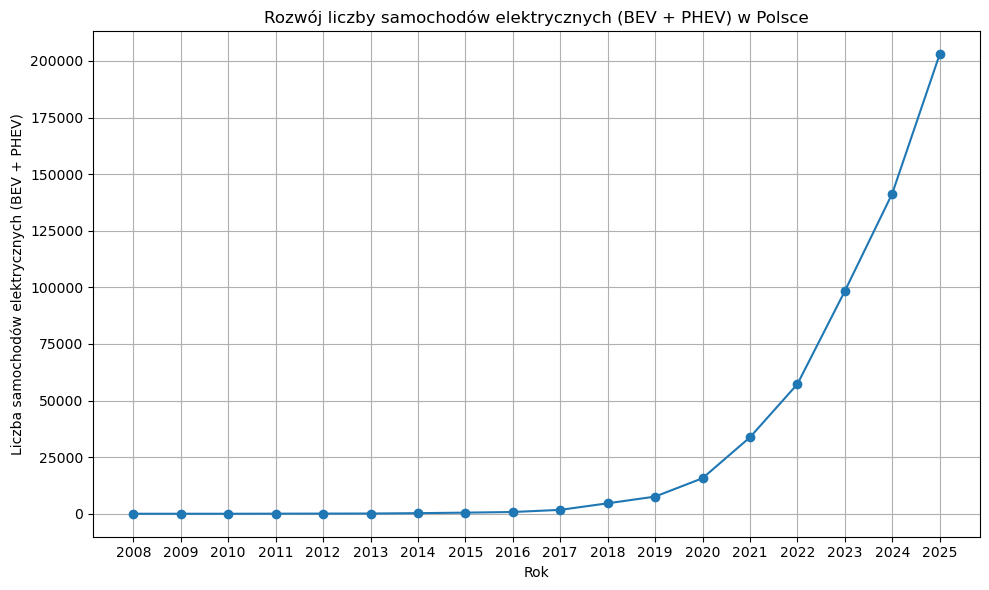

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane
df = pd.read_csv('Dane/Zrodla_danych/Polska/wszystkie.csv')


# Zamień kolumny na liczby
df['BEV'] = pd.to_numeric(df['BEV'], errors='coerce').fillna(0)
df['PHEV'] = pd.to_numeric(df['PHEV'], errors='coerce').fillna(0)
df['Rok'] = df['Category'].astype(int)

# Suma BEV + PHEV
df['BEV_PHEV'] = df['BEV'] + df['PHEV']

# Wykres liniowy
plt.figure(figsize=(10,6))
plt.plot(df['Rok'], df['BEV_PHEV'], marker='o')
plt.xlabel('Rok')
plt.ylabel('Liczba samochodów elektrycznych (BEV + PHEV)')
plt.title('Rozwój liczby samochodów elektrycznych (BEV + PHEV) w Polsce')
plt.grid(True)
plt.xticks(df['Rok'])
plt.tight_layout()
plt.show()

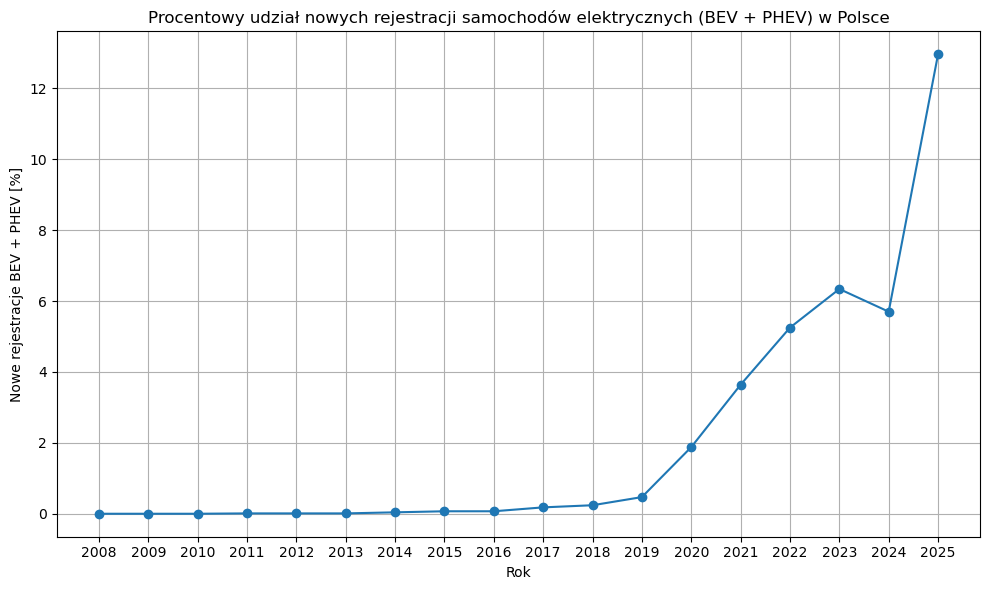

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane
df_new = pd.read_csv('Dane/Zrodla_danych/Polska/procent_nowych.csv')

# Zamień kolumny na liczby
df_new['BEV'] = pd.to_numeric(df_new['BEV'], errors='coerce').fillna(0)
df_new['PHEV'] = pd.to_numeric(df_new['PHEV'], errors='coerce').fillna(0)
df_new['Rok'] = df_new['Category'].astype(int)

# Suma BEV + PHEV
df_new['BEV_PHEV'] = df_new['BEV'] + df_new['PHEV']

# Wykres liniowy
plt.figure(figsize=(10,6))
plt.plot(df_new['Rok'], df_new['BEV_PHEV'], marker='o')
plt.xlabel('Rok')
plt.ylabel('Nowe rejestracje BEV + PHEV [%]')
plt.title('Procentowy udział nowych rejestracji samochodów elektrycznych (BEV + PHEV) w Polsce')
plt.grid(True)
plt.xticks(df_new['Rok'])
plt.tight_layout()
plt.show()

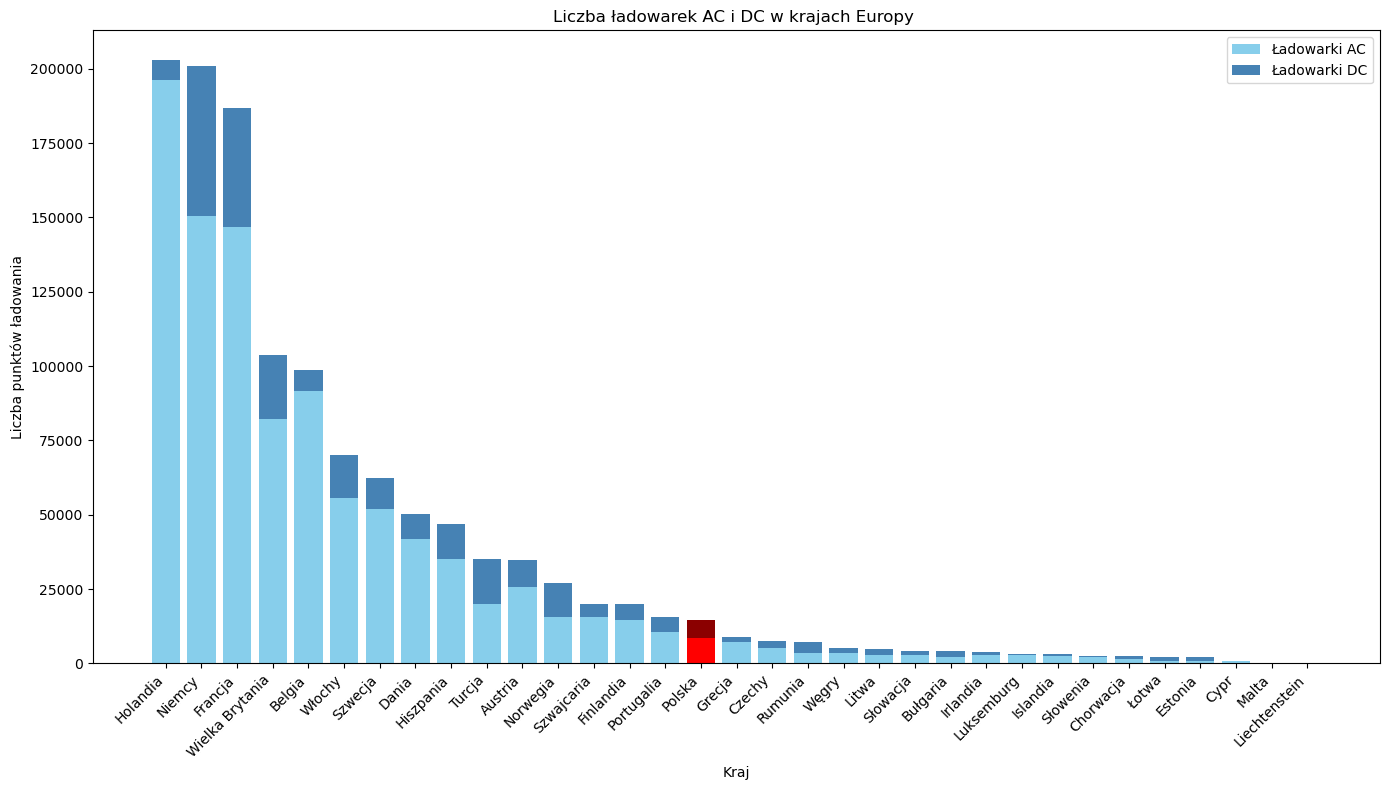

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytaj dane z pliku
df = pd.read_csv('chargers_export.csv')

# 2. Słownik tłumaczeń (rozszerzony o brakujące kraje z Twoich danych)
country_translation = {
    'Austria': 'Austria', 'Belgium': 'Belgia', 'Bulgaria': 'Bułgaria',
    'Croatia': 'Chorwacja', 'Cyprus': 'Cypr', 'Czech Republic': 'Czechy',
    'Denmark': 'Dania', 'Estonia': 'Estonia', 'Finland': 'Finlandia',
    'France': 'Francja', 'Germany': 'Niemcy', 'Greece': 'Grecja',
    'Hungary': 'Węgry', 'Iceland': 'Islandia', 'Ireland': 'Irlandia',
    'Italy': 'Włochy', 'Latvia': 'Łotwa', 'Liechtenstein': 'Liechtenstein',
    'Lithuania': 'Litwa', 'Luxembourg': 'Luksemburg', 'Malta': 'Malta',
    'Netherlands': 'Holandia', 'Norway': 'Norwegia', 'Poland': 'Polska',
    'Portugal': 'Portugalia', 'Romania': 'Rumunia', 'Slovakia': 'Słowacja',
    'Slovenia': 'Słowenia', 'Spain': 'Hiszpania', 'Sweden': 'Szwecja',
    'Switzerland': 'Szwajcaria', 'Turkey': 'Turcja', 'United Kingdom': 'Wielka Brytania'
}

# 3. Przygotowanie danych
df.rename(columns={'Category': 'Country'}, inplace=True)
df.fillna(0, inplace=True)

# Mapowanie z zabezpieczeniem przed wartościami NaN (kluczowe dla uniknięcia błędu)
df['Kraj'] = df['Country'].map(country_translation).fillna(df['Country'])

# Definicja kolumn AC i DC
ac_columns = [
    'Slow AC recharging point, single-phase (P < 7.4kW)',
    'Medium-speed AC recharging point, triple-phase (7.4kW ≤ P ≤ 22kW)',
    'Fast AC recharging point, triple-phase (P > 22kW)'
]
dc_columns = [
    'Slow DC recharging point (P < 50kW)',
    'Fast DC recharging point (50kW ≤ P < 150kW)',
    'Level 1 - Ultra-fast DC recharging point (150kW ≤ P < 350kW)',
    'Level 2 - Ultra-fast DC recharging point (P ≥ 350kW)'
]

# Obliczenia
df['AC'] = df[ac_columns].sum(axis=1)
df['DC'] = df[dc_columns].sum(axis=1)
df['Razem'] = df['AC'] + df['DC']

# Sortowanie według sumy
df_sorted = df.sort_values(by='Razem', ascending=False)

# 4. Przygotowanie kolorów (Polska na czerwono)
colors_ac = ['red' if k == 'Polska' else 'skyblue' for k in df_sorted['Kraj']]
colors_dc = ['darkred' if k == 'Polska' else 'steelblue' for k in df_sorted['Kraj']]

# 5. Tworzenie wykresu
plt.figure(figsize=(14, 8))

# Słupki AC
plt.bar(df_sorted['Kraj'], df_sorted['AC'], label='Ładowarki AC', color=colors_ac)

# Słupki DC nałożone na AC (stacked)
plt.bar(df_sorted['Kraj'], df_sorted['DC'], bottom=df_sorted['AC'], label='Ładowarki DC', color=colors_dc)

# Estetyka wykresu
plt.xlabel('Kraj')
plt.ylabel('Liczba punktów ładowania')
plt.title('Liczba ładowarek AC i DC w krajach Europy ')
plt.xticks(rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

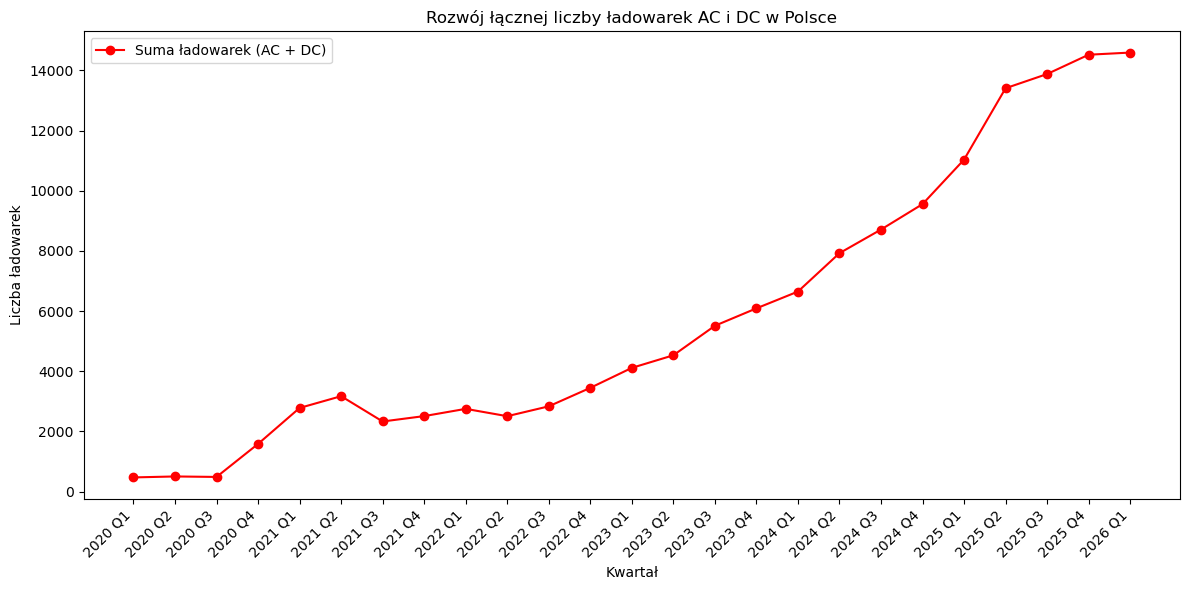

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane
df = pd.read_csv('poland_chargers_export.csv')

# Usuń wiersze z brakującymi danymi
df = df.dropna(subset=['AC', 'DC'])

# Zamień kolumny na liczby całkowite
df['AC'] = pd.to_numeric(df['AC'], errors='coerce').fillna(0).astype(int)
df['DC'] = pd.to_numeric(df['DC'], errors='coerce').fillna(0).astype(int)

# Oblicz sumę ładowarek
df['Suma'] = df['AC'] + df['DC']

# Oś X - kwartały
x_labels = df['Category']

plt.figure(figsize=(12, 6))
plt.plot(x_labels, df['Suma'], marker='o', color='red', label='Suma ładowarek (AC + DC)')
plt.xlabel('Kwartał')
plt.ylabel('Liczba ładowarek')
plt.title('Rozwój łącznej liczby ładowarek AC i DC w Polsce')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()
